<a href="https://colab.research.google.com/github/bisht-prachi/Flood-detection-from-SAR-imagery/blob/main/Copy_of_ECTI_Jumpstart.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Set up plotting options
%matplotlib inline

In [ ]:
# need to run and restart instance
!pip install -U git+https://github.com/albu/albumentations --no-cache-dir
!pip install segmentation-models-pytorch

  Cloning https://github.com/albu/albumentations to /tmp/pip-req-build-_u1i1yiq
  Running command git clone --filter=blob:none --quiet https://github.com/albu/albumentations /tmp/pip-req-build-_u1i1yiq
  Resolved https://github.com/albu/albumentations to commit c9cb7720132c1261db562bf6b5fd967acff5dc8c
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for albumentations: filename=albumentations-2.0.7-py3-none-any.whl size=367075 sha256=d2e8de7f9881e742ed5bf09a0df89e9911ea93ddc14d0ae4ed042bea4ffa440b
  Stored in directory: /tmp/pip-ephem-wheel-cache-efwp8foq/wheels/4d/17/00/8db11e688c525b1b4014b6adbc516b8cb4ce7e69488042e7e2
Successfully built albumentations
  Attempting uninstall: albumentations
    Found existing installation: albumentations 2.0.6
    Uninstalling albumentations-2.0.6:
      Successfully uninstalled albumentations-2.0.6
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/1

In [ ]:
# load packages
import os
import sys
import cv2
import gdown
import numpy as np
import pandas as pd
from glob import glob
import torch.nn as nn
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import segmentation_models_pytorch as smp

import torch
from torch.utils.data import Dataset, DataLoader

# Download dataset

In [ ]:
# check if files are already downloaded
dset_download = os.path.isdir('/content/ETCI_2021_Competition_Dataset/train/')

if dset_download is False:
  url = 'https://drive.google.com/uc?id=14HqNW5uWLS92n7KrxKgDwUTsSEST6LCr'
  output = 'train.tgz'
  gdown.download(url, output, quiet=False)

  url = 'https://drive.google.com/uc?id=1GWl3g1G152Rinxc1Fbc-JkSWlRQNWKBK'
  output = 'valid.tgz'
  gdown.download(url, output, quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=14HqNW5uWLS92n7KrxKgDwUTsSEST6LCr
From (redirected): https://drive.google.com/uc?id=14HqNW5uWLS92n7KrxKgDwUTsSEST6LCr&confirm=t&uuid=317f7086-8a29-4ca2-8d42-6f00005ea670
To: /content/train.tgz
100%|██████████| 3.23G/3.23G [00:42<00:00, 76.5MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1GWl3g1G152Rinxc1Fbc-JkSWlRQNWKBK
From (redirected): https://drive.google.com/uc?id=1GWl3g1G152Rinxc1Fbc-JkSWlRQNWKBK&confirm=t&uuid=3bfd915d-b57e-469b-a5c3-ea6c7a819fb6
To: /content/valid.tgz
100%|██████████| 873M/873M [00:05<00:00, 155MB/s]


### Move and unzip files

In [ ]:
if dset_download is False:
  !mkdir -p /content/ETCI_2021_Competition_Dataset

  !mv /content/train.tgz /content/ETCI_2021_Competition_Dataset/
  !mv /content/valid.tgz /content/ETCI_2021_Competition_Dataset/

  !unzip -q /content/ETCI_2021_Competition_Dataset/train.tgz -d /content/ETCI_2021_Competition_Dataset
  !unzip -q /content/ETCI_2021_Competition_Dataset/valid.tgz -d /content/ETCI_2021_Competition_Dataset

# Set path to where dataset is downloaded

In [ ]:
# path to dataset root directory
dset_root = '/content/ETCI_2021_Competition_Dataset/'

In [ ]:
print(os.listdir(dset_root))

['train.tgz', 'train', 'val', '__MACOSX', 'valid.tgz']


In [ ]:
# get number of training/validation regions
train_dir = os.path.join(dset_root, 'train')
val_dir = os.path.join(dset_root, 'val')

n_train_regions = len(glob(train_dir+'/*/'))
n_valid_regions = len(glob(val_dir+'/*/'))

# NOTE: make sure number of regions is NOT 0
print('Number of training temporal-regions: {}'.format(n_train_regions))
print('Number of validation temporal-regions: {}'.format(n_valid_regions))

Number of training temporal-regions: 31
Number of validation temporal-regions: 10


In [ ]:
glob(train_dir+'/northal_20190513t234653/tiles/**')

['/content/ETCI_2021_Competition_Dataset/train/northal_20190513t234653/tiles/flood_label',
 '/content/ETCI_2021_Competition_Dataset/train/northal_20190513t234653/tiles/water_body_label',
 '/content/ETCI_2021_Competition_Dataset/train/northal_20190513t234653/tiles/vv',
 '/content/ETCI_2021_Competition_Dataset/train/northal_20190513t234653/tiles/vh']

# Create train and val df

In [ ]:
def get_filename(filepath):
    return os.path.split(filepath)[1]


In [ ]:
vv_image_paths = sorted(glob(train_dir+'/**/vv/*.png', recursive=True))
vv_image_names = [get_filename(pth) for pth in vv_image_paths]
region_name_dates = ['_'.join(n.split('_')[:2]) for n in vv_image_names]


vh_image_paths, flood_label_paths, water_body_label_paths, region_names = [], [], [], []
for i in range(len(vv_image_paths)):
    # get vh image path
    vh_image_name = vv_image_names[i].replace('vv', 'vh')
    vh_image_path = os.path.join(train_dir, region_name_dates[i], 'tiles', 'vh', vh_image_name)
    vh_image_paths.append(vh_image_path)

    # get flood mask path
    flood_image_name = vv_image_names[i].replace('_vv', '')
    flood_label_path = os.path.join(train_dir, region_name_dates[i], 'tiles', 'flood_label', flood_image_name)
    flood_label_paths.append(flood_label_path)

    # get water body mask path
    water_body_label_name = vv_image_names[i].replace('_vv', '')
    water_body_label_path = os.path.join(train_dir, region_name_dates[i], 'tiles', 'water_body_label', water_body_label_name)
    water_body_label_paths.append(water_body_label_path)

    # get region name
    region_name = region_name_dates[i].split('_')[0]
    region_names.append(region_name)


train_paths = {'vv_image_path': vv_image_paths,
        'vh_image_path': vh_image_paths,
        'flood_label_path': flood_label_paths,
        'water_body_label_path': water_body_label_paths,
        'region': region_names
}


train_df = pd.DataFrame(train_paths)

print(train_df.shape)
train_df.head()

(33405, 5)


,vv_image_path,vh_image_path,flood_label_path,water_body_label_path,region
0,/content/ETCI_2021_Competition_Dataset/train/b...,/content/ETCI_2021_Competition_Dataset/train/b...,/content/ETCI_2021_Competition_Dataset/train/b...,/content/ETCI_2021_Competition_Dataset/train/b...,bangladesh
1,/content/ETCI_2021_Competition_Dataset/train/b...,/content/ETCI_2021_Competition_Dataset/train/b...,/content/ETCI_2021_Competition_Dataset/train/b...,/content/ETCI_2021_Competition_Dataset/train/b...,bangladesh
2,/content/ETCI_2021_Competition_Dataset/train/b...,/content/ETCI_2021_Competition_Dataset/train/b...,/content/ETCI_2021_Competition_Dataset/train/b...,/content/ETCI_2021_Competition_Dataset/train/b...,bangladesh
3,/content/ETCI_2021_Competition_Dataset/train/b...,/content/ETCI_2021_Competition_Dataset/train/b...,/content/ETCI_2021_Competition_Dataset/train/b...,/content/ETCI_2021_Competition_Dataset/train/b...,bangladesh
4,/content/ETCI_2021_Competition_Dataset/train/b...,/content/ETCI_2021_Competition_Dataset/train/b...,/content/ETCI_2021_Competition_Dataset/train/b...,/content/ETCI_2021_Competition_Dataset/train/b...,bangladesh


In [ ]:
vv_image_paths = sorted(glob(val_dir+'/**/vv/*.png', recursive=True))
vv_image_names = [get_filename(pth) for pth in vv_image_paths]
region_name_dates = ['_'.join(n.split('_')[:2]) for n in vv_image_names]


vh_image_paths, flood_label_paths, water_body_label_paths, region_names = [], [], [], []
for i in range(len(vv_image_paths)):
    # get vh image path
    vh_image_name = vv_image_names[i].replace('vv', 'vh')
    vh_image_path = os.path.join(val_dir, region_name_dates[i], 'tiles', 'vh', vh_image_name)
    vh_image_paths.append(vh_image_path)

    # get flood mask path ()
    flood_label_paths.append(np.nan)

    # get water body mask path
    water_body_label_name = vv_image_names[i].replace('_vv', '')
    water_body_label_path = os.path.join(val_dir, region_name_dates[i], 'tiles', 'water_body_label', water_body_label_name)
    water_body_label_paths.append(water_body_label_path)

    # get region name
    region_name = region_name_dates[i].split('_')[0]
    region_names.append(region_name)

valid_paths = {'vv_image_path': vv_image_paths,
        'vh_image_path': vh_image_paths,
        'flood_label_path': flood_label_paths,
        'water_body_label_path': water_body_label_paths,
        'region': region_names
}


val_df = pd.DataFrame(valid_paths)
val_df.sort_values(by=['vv_image_path'])  # important line for submitting results

print(val_df.shape)
val_df.head()

(10400, 5)


,vv_image_path,vh_image_path,flood_label_path,water_body_label_path,region
0,/content/ETCI_2021_Competition_Dataset/val/flo...,/content/ETCI_2021_Competition_Dataset/val/flo...,NaN,/content/ETCI_2021_Competition_Dataset/val/flo...,florence
1,/content/ETCI_2021_Competition_Dataset/val/flo...,/content/ETCI_2021_Competition_Dataset/val/flo...,NaN,/content/ETCI_2021_Competition_Dataset/val/flo...,florence
2,/content/ETCI_2021_Competition_Dataset/val/flo...,/content/ETCI_2021_Competition_Dataset/val/flo...,NaN,/content/ETCI_2021_Competition_Dataset/val/flo...,florence
3,/content/ETCI_2021_Competition_Dataset/val/flo...,/content/ETCI_2021_Competition_Dataset/val/flo...,NaN,/content/ETCI_2021_Competition_Dataset/val/flo...,florence
4,/content/ETCI_2021_Competition_Dataset/val/flo...,/content/ETCI_2021_Competition_Dataset/val/flo...,NaN,/content/ETCI_2021_Competition_Dataset/val/flo...,florence


# Visualize some images

In [ ]:
def to_rgb(vv_image, vh_image):
  ratio_image = np.clip(np.nan_to_num(vv_image/vh_image, 0), 0, 1)
  rgb_image = np.stack((vv_image, vh_image, 1-ratio_image), axis=2)
  return rgb_image

In [ ]:
def visualize(df_row):
  # vv = df_row['vv_image_path']
  # vh = df_row['vh_image_path']
  # water_body_label = df_row['water_body_label_path']
  # flood_label = df_row['flood_label_path']

  # vv = cv2.imread(vv, 0) / 255.0
  # vh = cv2.imread(vh, 0) / 255.0
  # water_body_label = cv2.imread(water_body_label, 0) / 255.0
  # flood_label = cv2.imread(flood_label, 0) / 255.0

  # ratio_image = np.clip(np.nan_to_num(vv/vh, 0), 0, 1)
  # rgb_image = np.stack((vh, vv, 1-ratio_image), axis=2)

  # print("Shape of RGB:", rgb_image.shape)
  # print("Shape of Water Body:", water_body_label.shape)
  # print("Shape of Flood:", flood_label.shape)

  # fig, ax = plt.subplots(1,3, figsize=(15,5))
  # ax[0].imshow(vv)
  # ax[0].set_title('rgb_image')
  # ax[1].imshow(water_body_label)#, cmap='gray')
  # ax[1].set_title('water_body_label')
  # ax[2].imshow(flood_label)
  # ax[2].set_title('flood_label')

  # plt.tight_layout()  # Adjust subplot parameters for a tight layout
  # plt.show()

  # get image paths
    vv_image_path = df_row['vv_image_path']
    vh_image_path = df_row['vh_image_path']
    flood_label_path = df_row['flood_label_path']
    water_body_label_path = df_row['water_body_label_path']

    # create RGB image from S1 images
    rgb_name = get_filename(vv_image_path).replace('_vv.png', '')
    vv_image = cv2.imread(vv_image_path, 0) / 255.0
    vh_image = cv2.imread(vh_image_path, 0) / 255.0
    rgb_image = to_rgb(vv_image, vh_image)

    # get flood label mask

    # get water body label mask
    water_body_label_image = cv2.imread(water_body_label_path, 0) / 255.0

    # plot images
    plt.figure(figsize=(15,5))
    if df_row.isnull().sum() > 0:
        # plot RGB S1 image
        plt.subplot(1,2,1)
        plt.imshow(rgb_image)
        plt.title(rgb_name)

        # plot water body mask
        plt.subplot(1,2,2)
        plt.imshow(water_body_label_image)
        plt.title('Water body mask')
    else:
        flood_label_image = cv2.imread(flood_label_path, 0) / 255.0

        # plot RGB S1 image
        plt.subplot(1,3,1)
        plt.imshow(rgb_image)
        plt.title(rgb_name)

        # plot flood label mask
        plt.subplot(1,3,2)
        plt.imshow(flood_label_image)
        plt.title('Flood mask')

        # plot water body mask
        plt.subplot(1,3,3)
        plt.imshow(water_body_label_image)
        plt.title('Water body mask')


In [ ]:
train_df.iloc[16601]['vh_image_path'],train_df.iloc[16601]['vv_image_path'], train_df.iloc[16601]['water_body_label_path'], train_df.iloc[16601]['flood_label_path']

('/content/ETCI_2021_Competition_Dataset/train/nebraska_20171210t002119/tiles/vh/nebraska_20171210t002119_x-13_y-28_vh.png',
 '/content/ETCI_2021_Competition_Dataset/train/nebraska_20171210t002119/tiles/vv/nebraska_20171210t002119_x-13_y-28_vv.png',
 '/content/ETCI_2021_Competition_Dataset/train/nebraska_20171210t002119/tiles/water_body_label/nebraska_20171210t002119_x-13_y-28.png',
 '/content/ETCI_2021_Competition_Dataset/train/nebraska_20171210t002119/tiles/flood_label/nebraska_20171210t002119_x-13_y-28.png')

In [ ]:
val_df.iloc[100]['vh_image_path'],val_df.iloc[100]['vv_image_path'], val_df.iloc[100]['water_body_label_path'], val_df.iloc[100]['flood_label_path']

('/content/ETCI_2021_Competition_Dataset/val/florence_20180510t231343/tiles/vh/florence_20180510t231343_x-11_y-28_vh.png',
 '/content/ETCI_2021_Competition_Dataset/val/florence_20180510t231343/tiles/vv/florence_20180510t231343_x-11_y-28_vv.png',
 '/content/ETCI_2021_Competition_Dataset/val/florence_20180510t231343/tiles/water_body_label/florence_20180510t231343_x-11_y-28.png',
 np.float64(nan))

<ipython-input-13-2c3873e7741d>:2: RuntimeWarning: divide by zero encountered in divide
  ratio_image = np.clip(np.nan_to_num(vv_image/vh_image, 0), 0, 1)
<ipython-input-13-2c3873e7741d>:2: RuntimeWarning: invalid value encountered in divide
  ratio_image = np.clip(np.nan_to_num(vv_image/vh_image, 0), 0, 1)


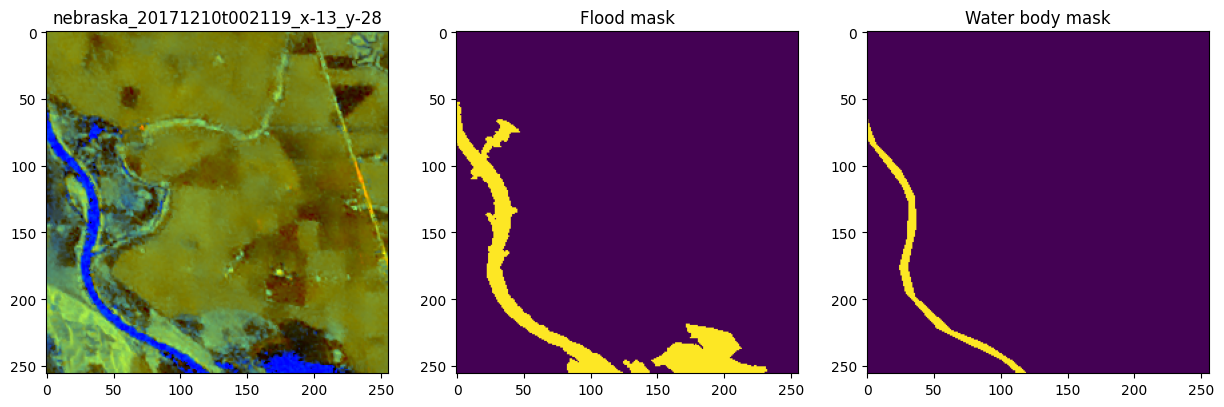

In [ ]:
visualize(train_df.iloc[16601])

<ipython-input-13-2c3873e7741d>:2: RuntimeWarning: invalid value encountered in divide
  ratio_image = np.clip(np.nan_to_num(vv_image/vh_image, 0), 0, 1)


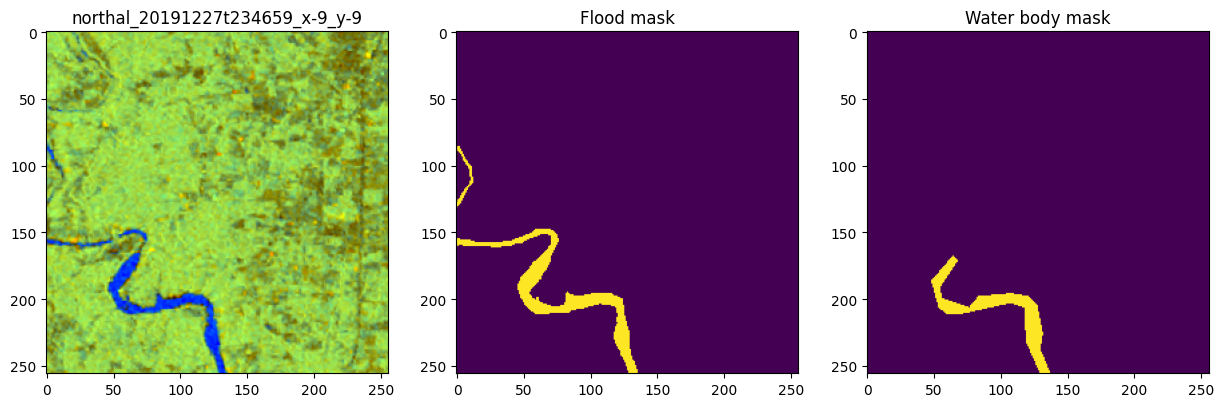

In [ ]:
visualize(train_df.iloc[-1])

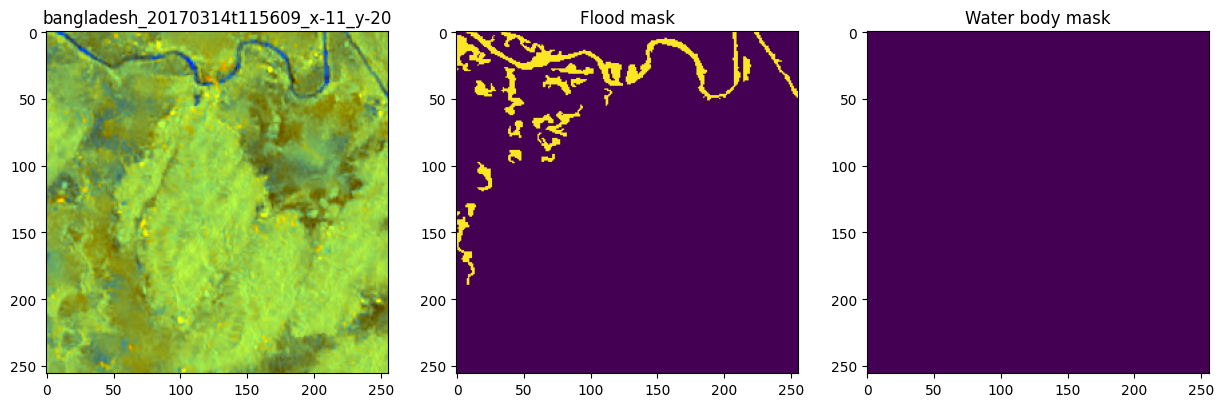

In [ ]:
visualize(train_df.iloc[100])

<ipython-input-13-2c3873e7741d>:2: RuntimeWarning: divide by zero encountered in divide
  ratio_image = np.clip(np.nan_to_num(vv_image/vh_image, 0), 0, 1)
<ipython-input-13-2c3873e7741d>:2: RuntimeWarning: invalid value encountered in divide
  ratio_image = np.clip(np.nan_to_num(vv_image/vh_image, 0), 0, 1)


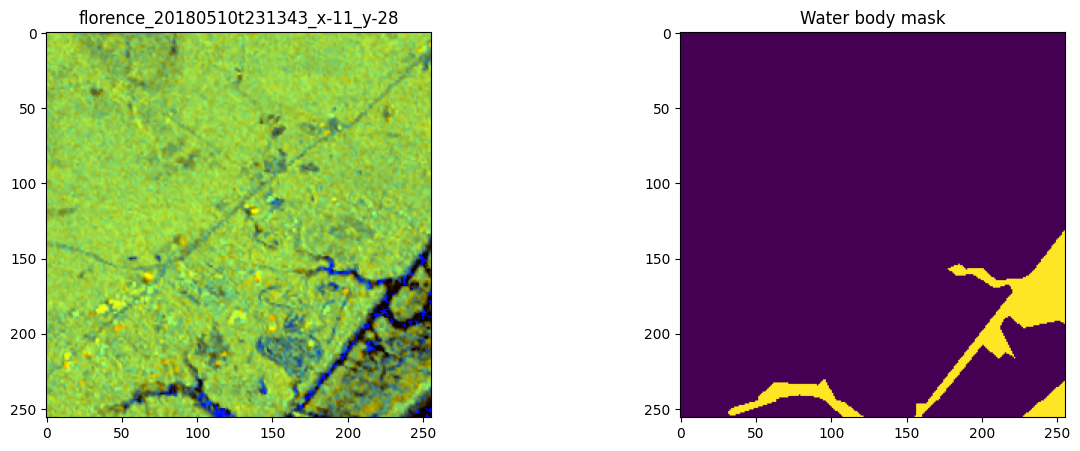

In [ ]:
visualize(val_df.iloc[100])

In [ ]:
# all regions in the training set
regions = ['nebraska', 'northal', 'bangladesh']

# randomly choose one for the development set and leave the rest for training
development_region = np.random.choice(regions, 1)[0]
regions.remove(development_region)
train_regions = regions

# filter the dataframe to only get images from specified regions
sub_train_df = train_df[train_df['region'] != development_region]
development_df = train_df[train_df['region'] == development_region]

# check that new dataframes only have the image paths from the correct regions
print('Sub-training set regions: {}'.format(np.unique(sub_train_df['region'].tolist())))
print('Development set region: {}'.format(np.unique(development_df['region'].tolist())))

Sub-training set regions: ['bangladesh' 'nebraska']
Development set region: ['northal']


# Preparing data for ML

In [ ]:
import albumentations as A

transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.RandomBrightnessContrast(p=0.2),
    A.RandomGamma(p=0.2),
    # A.Affine(scale=(0.8, 1.2), translate_percent=(0, 0.1), rotate=(-45, 45), shear=(-10, 10), p=0.5),
    A.GaussianBlur(blur_limit=3, p=0.2),
    # A.OpticalDistortion(p=0.3),
    # A.GridDistortion(p=.1),
    # A.HueSaturationValue(p=0.3),
    # A.CLAHE(p=0.3),
    A.Resize(256, 256),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))

])

In [ ]:
class SARdataset(Dataset):
  def __init__(self, df, split, transform=None):
    self.df = df
    self.split= split
    self.transform = transform

  def __len__(self):
    return len(self.df)

  def __getitem__(self, index):
    df_row = self.df.iloc[index]

    vv_image = cv2.imread(df_row['vv_image_path'], 0) / 255.0
    vh_image = cv2.imread(df_row['vh_image_path'], 0) / 255.0

    rgb_image = to_rgb(vv_image, vh_image)

    image_set = {}
    if self.split == 'test':
      image_set['image'] = rgb_image.transpose((2,0,1)).astype('float32')
      #only image
    else:
      flood_mask = cv2.imread(df_row['flood_label_path'], 0) / 255.0

      if self.transform:
        augmented = self.transform(image=rgb_image, mask=flood_mask)
        rgb_image = augmented['image']
        flood_mask = augmented['mask']

      image_set['image'] = rgb_image.transpose((2,0,1)).astype('float32')
      image_set['mask'] = flood_mask.astype('int64')


    # flood_mask = cv2.imread(df_row['flood_label_path'], 0) / 255.0 if self.split == 'train' else np.zeros_like(rgb_image[:,:,0])

    return image_set


In [ ]:
train_dataset  = SARdataset(sub_train_df, split='train', transform=transform)
dev_dataset = SARdataset(development_df, split='dev')

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=2, pin_memory=True)
dev_loader = DataLoader(dev_dataset, batch_size=16, shuffle=False, num_workers=2, pin_memory=True)

# DL Model

## (M) model

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [ ]:
import torchvision.models.segmentation as models
import segmentation_models_pytorch as smp

In [ ]:
def get_model(num_classes=2):#, weights=models.DeepLabV3_ResNet50_Weights.DEFAULT):
  # model = models.deeplabv3_resnet50(weights=weights)#encoder_weights='imagenet', classes=2)

  # model.classifier[4] = torch.nn.Conv2d(256, num_classes, kernel_size=1)

  model = smp.Unet(
      encoder_name="timm-efficientnet-b7",  # Specify the EfficientNetV2 backbone
      encoder_weights="imagenet",     # Use pre-trained weights
      in_channels=3,                  # Input image channels (RGB)
      classes=2,                      # Number of output classes (flood/no-flood)
  )


  return model


In [ ]:
model = get_model(num_classes=2)
model.to(device)

OutOfMemoryError: CUDA out of memory. Tried to allocate 2.00 MiB. GPU 0 has a total capacity of 14.74 GiB of which 2.12 MiB is free. Process 4685 has 14.74 GiB memory in use. Of the allocated memory 14.59 GiB is allocated by PyTorch, and 28.58 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

## (O) optimizer

In [ ]:

import torch.optim as optim
from torch.optim import lr_scheduler

optimizer = optim.AdamW(model.parameters(), lr=0.01)
scheduler = lr_scheduler.StepLR(optimizer, step_size=7,gamma=0.1)

## (L) Loss function

In [ ]:
# criterion = nn.CrossEntropyLoss()
criterion = nn.BCEWithLogitsLoss()

## (T) Training

### function to calculate iou score

In [ ]:
from sklearn.metrics import confusion_matrix

In [ ]:
def iou_score(preds, targets, num_classes=2):

  # initialize cm
  cm = np.zeros((num_classes, num_classes), dtype=int)

  preds = torch.argmax(preds, dim=1).flatten().cpu().numpy()
  targets = targets.flatten().cpu().numpy()

  cm = confusion_matrix(targets, preds)  # , labels=range(num_classes))

  # Check if confusion matrix is 2x2
  if cm.shape == (2, 2):
    tn, fp, fn, tp = cm.ravel()
    # compute IoU
    iou = tp / (tp + fp + fn + 1e-6)
  # For cases where confusion matrix is not 2x2 (e.g., only one class predicted)
  # we can either return 0 or handle it differently based on your needs
  else:
    iou = 0  # Or handle it based on your specific requirements

  return iou


In [ ]:
 torch.cuda.empty_cache()

In [ ]:
num_epochs = 3
best_iou = 0.0

for epoch in range(num_epochs):
    if device == 'cuda':
        torch.cuda.empty_cache()

    # ===== TRAINING =====
    model.train()
    train_loss = 0.0
    train_iou = 0.0

    pbar_train = tqdm(train_loader, desc=f"[Train Epoch {epoch+1}]")
    for batch in pbar_train:

       # load images and mask to device
        images = batch['image'].to(device)
        masks = batch['mask'].to(device)

        #set up the NN
        optimizer.zero_grad()
        outputs = model(images)['out'] #forward pass
        loss = criterion(outputs, masks)
        loss.backward() #backward pass
        optimizer.step()

        train_loss += loss.item()
        train_iou += iou_score(outputs, masks)

        # update tqdm bar
        pbar_train.set_postfix(loss=loss.item(), iou=train_iou / (pbar_train.n + 1))

    train_loss /= len(train_loader)
    train_iou /= len(train_loader)

    #step scheduler after training epoch
    scheduler.step()

    # ===== VALIDATION =====
    model.eval()
    dev_loss = 0.0
    dev_iou = 0.0

    pbar_val = tqdm(dev_loader, desc=f"[Val Epoch {epoch+1}]")
    with torch.no_grad():
        for batch in pbar_val:

            images = batch['image'].to(device)
            masks = batch['mask'].to(device)

            outputs = model(images)['out']
            loss = criterion(outputs, masks)

            dev_loss += loss.item()
            dev_iou += iou_score(outputs, masks)

            # update tqdm bar
            pbar_val.set_postfix(loss=loss.item(), iou=dev_iou / (pbar_val.n + 1))

            # if dev_iou > best_iou:
            #   best_iou = dev_iou
            #   torch.save(model.state_dict(), 'deeplabv3_best.pth')
            #   print(f"💾 Saved best model at epoch {epoch+1} with IoU {best_iou:.4f}")

    dev_loss /= len(dev_loader)
    dev_iou /= len(dev_loader)

    print(f"\nEpoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {train_loss:.4f}, Train IoU: {train_iou:.4f} | "
          f"Val Loss: {dev_loss:.4f}, Val IoU: {dev_iou:.4f}\n")


[Train Epoch 1]:   0%|          | 0/1152 [00:00<?, ?it/s]

<ipython-input-13-2c3873e7741d>:2: RuntimeWarning: divide by zero encountered in divide
  ratio_image = np.clip(np.nan_to_num(vv_image/vh_image, 0), 0, 1)
<ipython-input-13-2c3873e7741d>:2: RuntimeWarning: invalid value encountered in divide
  ratio_image = np.clip(np.nan_to_num(vv_image/vh_image, 0), 0, 1)
<ipython-input-13-2c3873e7741d>:2: RuntimeWarning: invalid value encountered in divide
  ratio_image = np.clip(np.nan_to_num(vv_image/vh_image, 0), 0, 1)
<ipython-input-13-2c3873e7741d>:2: RuntimeWarning: divide by zero encountered in divide
  ratio_image = np.clip(np.nan_to_num(vv_image/vh_image, 0), 0, 1)


OutOfMemoryError: CUDA out of memory. Tried to allocate 12.00 MiB. GPU 0 has a total capacity of 14.74 GiB of which 2.12 MiB is free. Process 4685 has 14.74 GiB memory in use. Of the allocated memory 14.59 GiB is allocated by PyTorch, and 28.58 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [ ]:
# save model
torch.save(model.state_dict(), 'model.pt')

# Load Model

In [ ]:
model = get_model()
model.load_state_dict(torch.load('model.pt'))
model.to(device)
model.eval()

# Test Model

In [ ]:
test_transform = A.Compose([
    A.Resize(256, 256),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))

])

In [ ]:
test_dataset = SARdataset(val_df, split='test', transform=test_transform)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=2, pin_memory=True)

In [ ]:
def visualize_result(df_row, prediction, figsize=[25, 15]):
    vv_image = cv2.imread(df_row['vv_image_path'], 0) / 255.0
    vh_image = cv2.imread(df_row['vh_image_path'], 0) / 255.0
    rgb_input = to_rgb(vv_image, vh_image)

    plt.figure(figsize=tuple(figsize))
    plt.subplot(1,2,1)
    plt.imshow(rgb_input)
    plt.title('RGB w/ result')
    plt.subplot(1,2,2)
    plt.imshow(prediction)
    plt.title('Result')

In [ ]:
final_predictions = []

model.eval()
with torch.no_grad():
    for batch in tqdm(test_loader):
        # load image and mask into device memory
        image = batch['image'].to(device)

        # pass images into model
        pred = model(image)

        # Access the output tensor from the OrderedDict
        output_tensor = pred['out']

        # compute class predictions, i.e. flood or no-flood
        class_pred = output_tensor.argmax(dim=1)

        # convert class prediction to numpy
        class_pred = class_pred.detach().cpu().numpy()

        # add to final predictions
        final_predictions.append(class_pred.astype('uint8'))


# this should give you a result of 0.4 on ranking board
final_predictions = np.concatenate(final_predictions, axis=0)

# check final prediction shape
print(final_predictions.shape)

In [ ]:
index = -1910
visualize_result(val_df.iloc[index], final_predictions[index], figsize=(17,10))

In [ ]:
index = 252
visualize_result(val_df.iloc[index], final_predictions[index], figsize=(17,10))

In [ ]:
index = -1910
visualize_result(val_df.iloc[index], final_predictions[index], figsize=(17,10))